In [7]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.lines import Line2D

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import matplotlib.dates as mdates
import numpy as np

import intake

import sys
sys.path.append("/work/mh1498/m301248/TCO_data/COARE-algorithm/Python/COARE3.5/") 
sys.path.append("/work/mh1498/m301248/TCO_data/BCO_observational/mass_fluxes_profiles/yk22_mass_fluxes.py")
# sys.path.append("/Users/alessandrostorer/Desktop/PhD/1st_yy/work/codes/COARE3.5/") 
# sys.path.append("/Users/alessandrostorer/Desktop/PhD/1st_yy/work/codes/BCO_observational/mass_fluxes_profiles/yk22_mass_fluxes.py")

import meteo
import yk22_mass_fluxes

import metpy




import pandas as pd
from IPython.display import display, HTML

In [2]:
%load_ext autoreload
%autoreload 2

### global parameters

In [3]:
## what is the reference layer to compute mixed layer AVERAGED quantities?
mixed_avg_levels   = slice(200, 400)

Rd = 287.
cp = 1004. # j / kg K
Lv = 2.5e6 # J/kg
g = 9.81   # m/s2


Fa_q_eu, Fa_q_or    = (-2e-3)/86400. , (-0.e-3)/86400.   # kg/kg / day
Fa_th_eu , Fa_th_or = -0.75/86400.,       -0./86400.        # K/day
bl_height        = 500.                                    #  mean mixed layer height / m
bl_density       = 1. 


In [4]:
## what height is entrained air from?
entrainment_levels = slice(600, 850)    # m

## what height does convective downdrafts come from?
downdraft_levels_eu = slice(1000, 2000)
downdraft_levels_or = slice(2500, 3500)

#### load profiles

In [5]:
min_hgt = 40.

level2_path = "/work/mh1498/m301248/TCO_data/eurec4a_profiles_level2/EUREC4A_BCO_Vaisala-RS_L2_v3.0.0.nc"
level2_path_local = "/Users/alessandrostorer/Desktop/PhD/1st_yy/work/datasets/radiosondes_3/EUREC4A_BCO_Vaisala-RS_L2_v3.0.0.nc"

ds_eureca = xr.open_dataset(level2_path)
ds_eureca_bco = ds_eureca.where(((ds_eureca["platform"] == 1)&(ds_eureca["ascent_flag"]==1)&(ds_eureca.alt>min_hgt)), drop=True)
## renaming for common ground
ds_eureca_bco = ds_eureca_bco.swap_dims({"sounding": "launch_time"})
ds_eureca_bco = ds_eureca_bco.rename({"alt":"height"})


ds_orcestra = xr.open_dataset("ipfs://bafybeid7cnw62zmzfgxcvc6q6fa267a7ivk2wcchbmkoyk4kdi5z2yj2w4", engine="zarr")
ds_orcestra
ds_orcestra_bco = ds_orcestra.where(((ds_orcestra["platform"] == "BCO")&(ds_orcestra["ascent_flag"]==0)&(ds_orcestra.height>min_hgt)), drop=True)


In [9]:
## campaign-mean profiles
rh_eu = ds_eureca_bco.rh.mean(dim="launch_time")
wind_eu = ds_eureca_bco.wspd.mean(dim="launch_time")
temp_eu = ds_eureca_bco.ta.mean(dim="launch_time")
theta_eu = ds_eureca_bco.theta.mean(dim="launch_time")
q_eu = ds_eureca_bco.q.mean(dim="launch_time")
press_eu = ds_eureca_bco.p.mean(dim="launch_time")


## to draw profiles of thetaD, qD
props_eu = yk22_mass_fluxes.properties_from_profile(ds_eureca_bco.mean(dim="launch_time"),
                                                    mixed_avg_levels=mixed_avg_levels,
                                                    entrainment_levels=entrainment_levels,
                                                    downdraft_levels=downdraft_levels_eu, 
                                                    CD_sat_frac=1.,
                                                    vert_dim="height")






rh_or = ds_orcestra_bco.rh.mean(dim="launch_time")
wind_or = ds_orcestra_bco.wspd.mean(dim="launch_time")
temp_or = ds_orcestra_bco.ta.mean(dim="launch_time")
theta_or = ds_orcestra_bco.theta.mean(dim="launch_time")
q_or = ds_orcestra_bco.q.mean(dim="launch_time")
press_or = ds_orcestra_bco.p.mean(dim="launch_time")


## to draw profiles of thetaD, qD
props_or = yk22_mass_fluxes.properties_from_profile(ds_orcestra_bco.mean(dim="launch_time"),
                                                    mixed_avg_levels=mixed_avg_levels,
                                                    entrainment_levels=entrainment_levels,
                                                    downdraft_levels=downdraft_levels_or, 
                                                    CD_sat_frac=1.,
                                                    vert_dim="height")




#### load radiances

In [10]:
ingr_path_local = "/Users/alessandrostorer/Desktop/PhD/1st_yy/work/datasets/ingredients_fluxes/EUREC4A_IngrFlux.nc"
ingr_path = "/work/mh1498/m301248/TCO_data/fluxes_data/EUREC4A_IngrFlux.nc"
ingr_eu = xr.open_dataset(ingr_path)

ingr_path_local = "/Users/alessandrostorer/Desktop/PhD/1st_yy/work/datasets/ingredients_fluxes/ORCESTRA_IngrFlux.nc"
ingr_path = "/work/mh1498/m301248/TCO_data/fluxes_data/ORCESTRA_IngrFlux.nc"
ingr_or = xr.open_dataset(ingr_path)

generate samples of wind speed and SST and study how these affect the resulting mass fluxes

In [11]:
import coare35vn

#### EUREC4A conditions

In [45]:
n_u, n_sst = 20, 20

# ---- 1. Sensitivity grid -------------------------------------------------
u = np.linspace(1, 20, n_u)          # wind speed [m/s]
ts = np.linspace(300, 303, n_sst)    # SST [K]

U, TS = np.meshgrid(u, ts, indexing="ij")   # shape (n_u, n_sst)
grid_shape = U.shape

# Fixed parameters
t0 = float(np.squeeze(temp_eu.isel(height=0).values))   # scalar air temp [K]
rh = 0.7
P = 1013.
Rs = ingr_eu.sw_global.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"]).values
Rl = ingr_eu.lw_diff.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"]).values



def full(val):
    """Constant array with the size of the flattened grid."""
    return np.full(U.size, val, dtype=float)


# ---- 2. Bulk fluxes on the whole grid (one vectorized call) --------------
output = np.asarray(
    coare35vn.coare35vn(u=U.ravel(),
              t=full(t0 - 273.15),
              rh=full(100 * rh),
              ts=TS.ravel() - 273.15,
              P=full(P), Rs=full(Rs), Rl=full(Rl),
              zu=50, zt=50, zq=50, lat=13, zi=600,
              rain=None, cp=None, sigH=None, jcool=1)
).squeeze()

# Make sure the variable axis comes first: (k, N)
if output.shape[0] == U.size and output.shape[-1] != U.size:
    output = output.T

shf = output[0].reshape(grid_shape)   # sensible heat flux
lhf = output[1].reshape(grid_shape)   # latent heat flux


# ---- 3. Propagate through solve_qTh_equations ----------------------------
def to_vec(res):
    """Return (values, names) for the scalar outputs, whatever the container."""
    if isinstance(res, xr.Dataset):
        names = list(res.data_vars)
        vals = [float(res[k].values) for k in names]
    elif isinstance(res, dict):
        names = list(res.keys())
        vals = [float(np.squeeze(getattr(v, "values", v))) for v in res.values()]
    else:  # DataArray / ndarray / list
        vals = np.ravel(np.asarray(res)).astype(float).tolist()
        names = None
    return np.array(vals), names


E_CD, names = None, None
for i in range(n_u):
    for j in range(n_sst):
        res, _, _ = yk22_mass_fluxes.solve_qTh_equations(
            props_eu, shf[i, j], lhf[i, j], -10., Fa_q_eu, Fa_th_eu
        )
        vec, nm = to_vec(res)
        if E_CD is None:  # allocate on first call
            E_CD = np.full(grid_shape + (vec.size,), np.nan)
            names = nm if nm is not None else [f"out{k}" for k in range(vec.size)]
        E_CD[i, j, :] = vec

# ---- 4. Package as labelled DataArrays -----------------------------------
E_CD_da = xr.DataArray(
    E_CD,
    dims=("u", "ts", "component"),
    coords={"u": u, "ts": ts, "component": names},
    name="E_CD_eu",
)
shf_da = xr.DataArray(shf, dims=("u", "ts"), coords={"u": u, "ts": ts}, name="shf")
lhf_da = xr.DataArray(lhf, dims=("u", "ts"), coords={"u": u, "ts": ts}, name="lhf")


/work/mh1498/m301248/TCO_data/COARE-algorithm/Python/COARE3.5/meteo.py:157: RuntimeWarning: invalid value encountered in power
  psi = -((1 + 0.6667*zet)**1.5 + 0.6667*(zet - 14.28)*exp(-dzet) + 8.525)


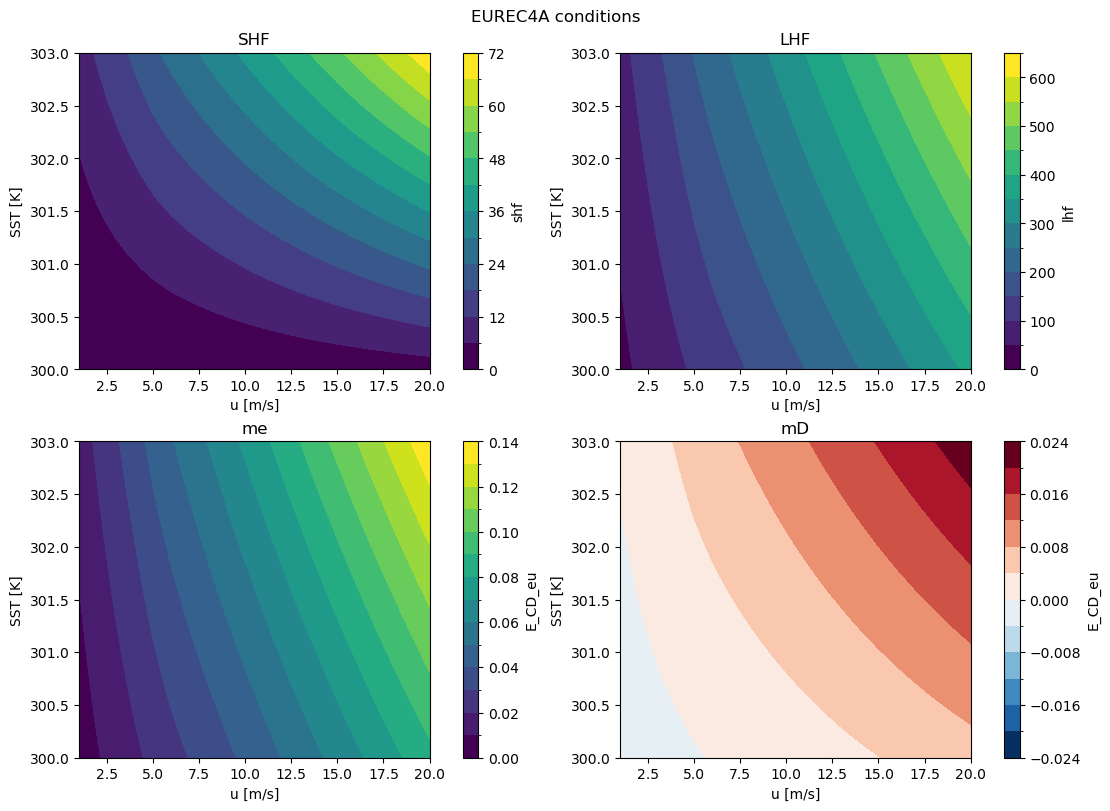

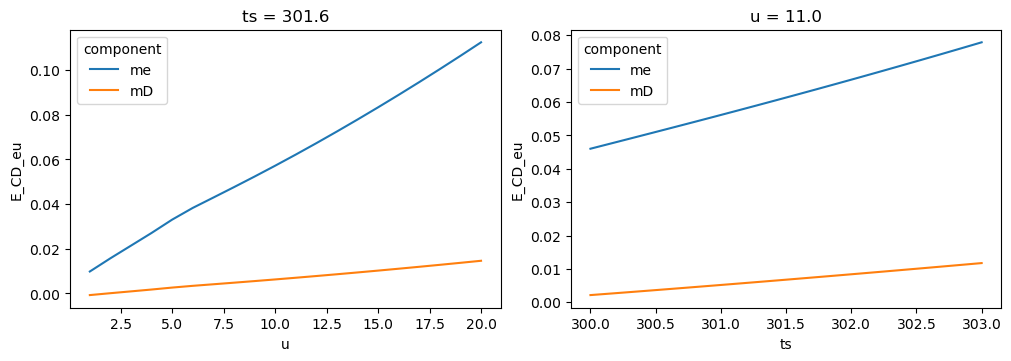

In [46]:
# ---- 5. Visualize --------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
fig.suptitle("EUREC4A conditions")
panels = [
    (shf_da, "SHF"),
    (lhf_da, "LHF"),
    (E_CD_da.sel(component=names[0]), str(names[0])),
    (E_CD_da.sel(component=names[1]), str(names[1])),
]

for ax, (da, title) in zip(axes.ravel(), panels):
    da.transpose("ts", "u").plot.contourf(ax=ax, levels=15, add_colorbar=True)
    ax.set_title(title)
    ax.set_xlabel("u [m/s]")
    ax.set_ylabel("SST [K]")
plt.show()

# One-at-a-time slices: sensitivity to u at mid SST, and to ts at mid u
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
E_CD_da.isel(ts=n_sst // 2).plot.line(x="u", hue="component", ax=ax[0])
E_CD_da.isel(u=n_u // 2).plot.line(x="ts", hue="component", ax=ax[1])
plt.show()

#### ORCESTRA conditions

In [42]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

n_u, n_sst = 20, 20

# ---- 1. Sensitivity grid -------------------------------------------------
u = np.linspace(1, 10, n_u)          # wind speed [m/s]
ts = np.linspace(303, 305, n_sst)    # SST [K]

U, TS = np.meshgrid(u, ts, indexing="ij")   # shape (n_u, n_sst)
grid_shape = U.shape

# Fixed parameters
t0 = float(np.squeeze(temp_or.isel(height=0).values))   # scalar air temp [K]
rh = 0.7
P = 1013.
Rs = ingr_or.sw_global.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"]).values
Rl = ingr_or.lw_diff.sel(cell=[17,24,31,18,25,32, 19,26,33]).mean(dim=["cell", "time"]).values



def full(val):
    """Constant array with the size of the flattened grid."""
    return np.full(U.size, val, dtype=float)


# ---- 2. Bulk fluxes on the whole grid (one vectorized call) --------------
output = np.asarray(
    coare35vn.coare35vn(u=U.ravel(),
              t=full(t0 - 273.15),
              rh=full(100 * rh),
              ts=TS.ravel() - 273.15,
              P=full(P), Rs=full(Rs), Rl=full(Rl),
              zu=50, zt=50, zq=50, lat=13, zi=600,
              rain=None, cp=None, sigH=None, jcool=1)
).squeeze()

# Make sure the variable axis comes first: (k, N)
if output.shape[0] == U.size and output.shape[-1] != U.size:
    output = output.T

shf = output[0].reshape(grid_shape)   # sensible heat flux
lhf = output[1].reshape(grid_shape)   # latent heat flux


# ---- 3. Propagate through solve_qTh_equations ----------------------------
def to_vec(res):
    """Return (values, names) for the scalar outputs, whatever the container."""
    if isinstance(res, xr.Dataset):
        names = list(res.data_vars)
        vals = [float(res[k].values) for k in names]
    elif isinstance(res, dict):
        names = list(res.keys())
        vals = [float(np.squeeze(getattr(v, "values", v))) for v in res.values()]
    else:  # DataArray / ndarray / list
        vals = np.ravel(np.asarray(res)).astype(float).tolist()
        names = None
    return np.array(vals), names


E_CD, names = None, None
for i in range(n_u):
    for j in range(n_sst):
        res, _, _ = yk22_mass_fluxes.solve_qTh_equations(
            props_or, shf[i, j], lhf[i, j], -10., Fa_q_or, Fa_th_or
        )
        vec, nm = to_vec(res)
        if E_CD is None:  # allocate on first call
            E_CD = np.full(grid_shape + (vec.size,), np.nan)
            names = nm if nm is not None else [f"out{k}" for k in range(vec.size)]
        E_CD[i, j, :] = vec

# ---- 4. Package as labelled DataArrays -----------------------------------
E_CD_da = xr.DataArray(
    E_CD,
    dims=("u", "ts", "component"),
    coords={"u": u, "ts": ts, "component": names},
    name="E_CD_eu",
)
shf_da = xr.DataArray(shf, dims=("u", "ts"), coords={"u": u, "ts": ts}, name="shf")
lhf_da = xr.DataArray(lhf, dims=("u", "ts"), coords={"u": u, "ts": ts}, name="lhf")


/work/mh1498/m301248/TCO_data/COARE-algorithm/Python/COARE3.5/meteo.py:157: RuntimeWarning: invalid value encountered in power
  psi = -((1 + 0.6667*zet)**1.5 + 0.6667*(zet - 14.28)*exp(-dzet) + 8.525)


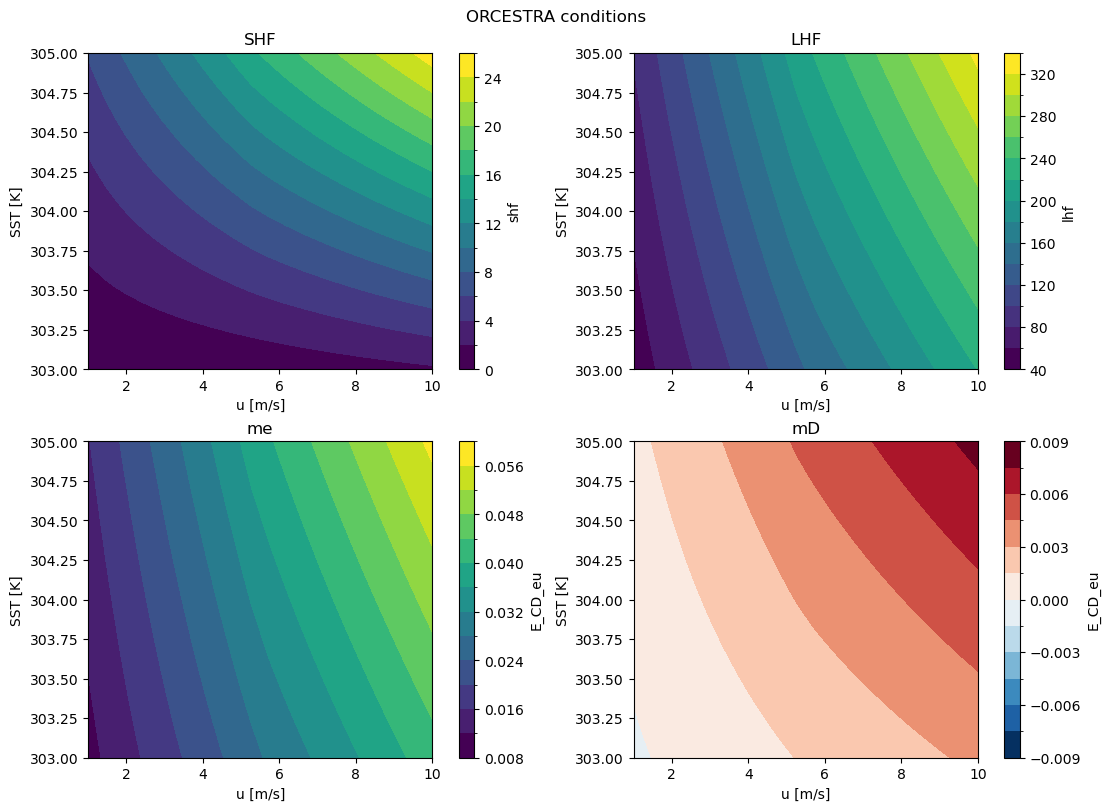

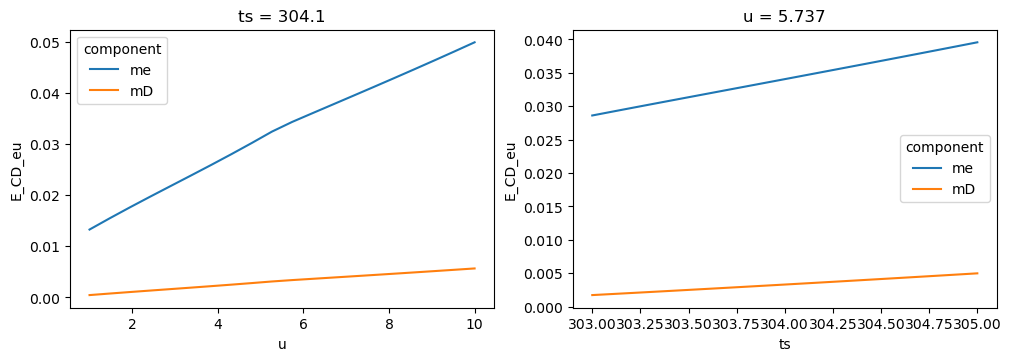

In [43]:
# ---- 5. Visualize --------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
fig.suptitle("ORCESTRA conditions")
panels = [
    (shf_da, "SHF"),
    (lhf_da, "LHF"),
    (E_CD_da.sel(component=names[0]), str(names[0])),
    (E_CD_da.sel(component=names[1]), str(names[1])),
]

for ax, (da, title) in zip(axes.ravel(), panels):
    da.transpose("ts", "u").plot.contourf(ax=ax, levels=15, add_colorbar=True)
    ax.set_title(title)
    ax.set_xlabel("u [m/s]")
    ax.set_ylabel("SST [K]")
plt.show()

# One-at-a-time slices: sensitivity to u at mid SST, and to ts at mid u
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5), constrained_layout=True)
E_CD_da.isel(ts=n_sst // 2).plot.line(x="u", hue="component", ax=ax[0])
E_CD_da.isel(u=n_u // 2).plot.line(x="ts", hue="component", ax=ax[1])
plt.show()